# 02 · Programs as hypotheses
### A visual laboratory for typed grammars, interpretation, and inverse reasoning

**Question:** Instead of adjusting weights inside a fixed network, can we discover a short
program that explains a set of examples?

You will build a tiny language for colored grids, execute its programs, enumerate legal
candidates, and inspect why several programs can fit the same observations. Then you will
reason backward through an operation that loses information.

**Prerequisites:** Python functions, recursion, dictionaries, and NumPy arrays. Lessons 00–01
supply the motivation, but there is no neural-network training here. **Time:** 75–120 minutes
with exercises. Install the shared `learn/vector_01/requirements.txt`; no new dependencies,
GPU, downloaded dataset, or network access is needed. Run all cells from the top, from any
working directory. Saved outputs let you read before executing.

Our grids are original synthetic examples inspired by the representation problems in ARC.
This is neither an ARC benchmark nor an ARC solver. The purpose is to expose the mechanics
that neural guidance will eventually direct.

**Route:** language → tree → interpreter → typed enumeration → ambiguity → behavioral
signatures → inverse constraints → forward/backward meeting.

In [1]:
from dataclasses import dataclass
from itertools import product
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import FancyBboxPatch
from IPython.display import display, Markdown
plt.rcParams.update({'figure.dpi':105,'font.size':10,'axes.spines.top':False,'axes.spines.right':False})
GRID_CMAP=ListedColormap(['#f1f5f9','#2563eb','#dc2626','#16a34a'])
MASK_CMAP=ListedColormap(['#111827','#ffffff'])

def show_grid(ax, value, title='', mask=False):
    value=np.asarray(value)
    ax.imshow(value,cmap=MASK_CMAP if mask else GRID_CMAP,
              norm=BoundaryNorm([-.5,.5,1.5],2) if mask else BoundaryNorm([-.5,.5,1.5,2.5,3.5],4))
    ax.set_title(title,fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xticks(np.arange(-.5,value.shape[1],1),minor=True)
    ax.set_yticks(np.arange(-.5,value.shape[0],1),minor=True)
    ax.grid(which='minor',color='#94a3b8',linewidth=.7)
    ax.tick_params(which='both',bottom=False,left=False,labelbottom=False,labelleft=False)
print('Colors: 0 background, 1 blue, 2 red, 3 green. Masks: white=True.')

Colors: 0 background, 1 blue, 2 red, 3 green. Masks: white=True.


## 1 · What is the hypothesis?

In lesson 01 the operator slots were fixed, and gradients fitted their numerical arguments.
Now the hypothesis is a **program tree**: which operators appear and how their outputs
connect. For examples $D=\{(x_i,y_i)\}$, a consistent program satisfies

$$\forall i,\quad \llbracket p\rrbracket(x_i)=y_i.$$

$\llbracket p\rrbracket$ means *the function obtained by executing program p*. It separates
syntax (the tree) from semantics (what the tree does).

| Piece | In this notebook | Why it matters |
|---|---|---|
| Language / DSL | A small grid-specific vocabulary | Determines which rules are expressible |
| Type system | Grid, Mask, Color | Rejects incompatible compositions |
| Interpreter | Recursive execution of a tree | Gives each candidate precise meaning |
| Search | Enumerate trees in increasing node count | Decides which candidates are examined |
| Specification | Exact input/output examples | Decides which candidates fit |

These are separate choices. A fast search cannot recover a rule absent from its language.
A correct interpreter does not resolve ambiguity in the observations.

## 2 · Define a small typed language

Colors are categorical labels, not magnitudes. A Mask is a Boolean array; a Grid is an
integer array. Both are nonempty two-dimensional arrays. The coarse types do not encode
shape; runtime checks handle shape compatibility. All operators preserve the input shape.

| Expression | Type signature | Exact meaning |
|---|---|---|
| `input` | Grid | Current example's grid |
| `blue`, `red`, `green` | Color | Constants 1, 2, 3 |
| `select(g,c)` | Grid × Color → Mask | True exactly where grid equals color |
| `flip(m)` | Mask → Mask | Reverse column order (horizontal reflection) |
| `right(m)` | Mask → Mask | Shift one column right; drop last column; fill left with False |
| `union(a,b)` | Mask × Mask → Mask | Elementwise Boolean OR; shapes must agree |
| `paint(m,c)` | Mask × Color → Grid | Color c where True, background elsewhere |

`paint` makes a fresh grid, not an overlay on the original. `right` does **not** wrap around.
These details are part of the hypothesis language, not implementation trivia.

A grammar tells us which trees exist. For example:
$\text{Mask} ::= \text{select(Grid, Color)}\mid\text{flip(Mask)}\mid
\text{right(Mask)}\mid\text{union(Mask,Mask)}$.
The recursive references allow infinitely many trees; a node budget makes our search finite.

In [2]:
@dataclass(frozen=True)
class Expr:
    op: str
    args: tuple = ()

SIGNATURES={
    'input': ((), 'Grid'),
    'blue': ((), 'Color'), 'red': ((), 'Color'), 'green': ((), 'Color'),
    'select': (('Grid','Color'),'Mask'),
    'flip': (('Mask',),'Mask'), 'right': (('Mask',),'Mask'),
    'union': (('Mask','Mask'),'Mask'), 'paint': (('Mask','Color'),'Grid'),
}
COLORS={'blue':1,'red':2,'green':3}

def infer_type(expr):
    if not isinstance(expr,Expr) or expr.op not in SIGNATURES:
        raise TypeError('Unknown expression or operation')
    expected,result=SIGNATURES[expr.op]
    actual=tuple(infer_type(child) for child in expr.args)
    if actual != expected:
        raise TypeError(f'{expr.op} expects {expected}, received {actual}')
    return result

def node_count(expr):
    return 1+sum(node_count(a) for a in expr.args)

def pretty(expr):
    return expr.op if not expr.args else expr.op+'('+', '.join(pretty(a) for a in expr.args)+')'

INPUT,BLUE,RED,GREEN=(Expr(name) for name in ['input','blue','red','green'])
SELECT_BLUE=Expr('select',(INPUT,BLUE))
SHIFT_RULE=Expr('paint',(Expr('right',(SELECT_BLUE,)),RED))
FLIP_RULE=Expr('paint',(Expr('flip',(SELECT_BLUE,)),RED))
print(pretty(SHIFT_RULE), '| type:',infer_type(SHIFT_RULE),'| nodes:',node_count(SHIFT_RULE))
try:
    infer_type(Expr('right',(BLUE,)))
except TypeError as exc:
    print('Rejected before execution:',exc)
else:
    raise AssertionError('Invalid typed program was accepted')

paint(right(select(input, blue)), red) | type: Grid | nodes: 6
Rejected before execution: right expects ('Mask',), received ('Color',)


## 3 · Execute the tree, not a string of Python

A tree is structured data. The interpreter recursively evaluates its children, then applies
an operator to the results. It never calls Python `eval`. This makes the allowed behavior
explicit and lets us count, inspect, and search expressions.

All operations are deterministic and side-effect free: they do not mutate an example or
another subtree's value. This property will matter when comparing intermediate behaviors.

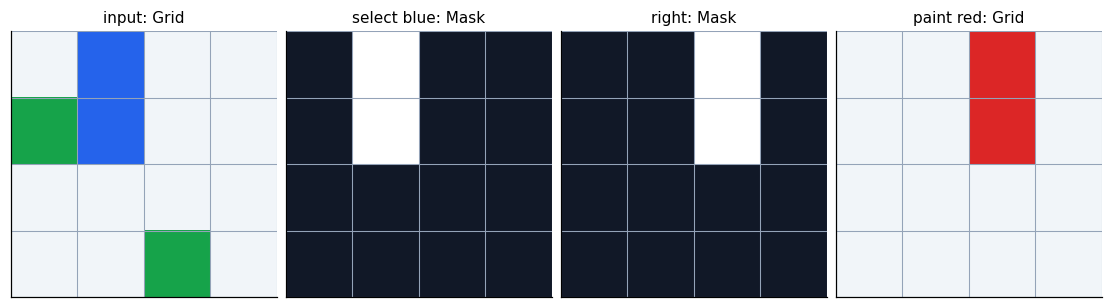

In [3]:
def right(mask):
    result=np.zeros_like(mask,dtype=bool)
    result[:,1:]=mask[:,:-1]
    return result

def apply_op(op, values):
    if op=='select': return values[0] == values[1]
    if op=='flip': return values[0][:,::-1].copy()
    if op=='right': return right(values[0])
    if op=='union':
        if values[0].shape != values[1].shape: raise ValueError('Mask shapes must match')
        return np.logical_or(values[0],values[1])
    if op=='paint': return np.where(values[0],values[1],0).astype(np.int64)
    raise ValueError(f'Not a callable operator: {op}')

def interpret(expr, grid):
    infer_type(expr)
    grid=np.asarray(grid)
    if grid.ndim!=2 or min(grid.shape)==0 or not np.issubdtype(grid.dtype,np.integer):
        raise ValueError('Expected a nonempty 2D integer grid')
    if np.any((grid<0)|(grid>3)): raise ValueError('Allowed colors: 0, 1, 2, 3')
    def visit(node):
        if node.op=='input': return grid.copy()
        if node.op in COLORS: return COLORS[node.op]
        return apply_op(node.op,tuple(visit(child) for child in node.args))
    return visit(expr)

example=np.array([[0,1,0,0],[3,1,0,0],[0,0,0,0],[0,0,3,0]])
original=example.copy()
selected=interpret(SELECT_BLUE,example)
shifted=interpret(Expr('right',(SELECT_BLUE,)),example)
prediction=interpret(SHIFT_RULE,example)
np.testing.assert_array_equal(example,original)
fig,axes=plt.subplots(1,4,figsize=(10,3),layout='constrained')
for ax,value,title,is_mask in zip(axes,[example,selected,shifted,prediction],
        ['input: Grid','select blue: Mask','right: Mask','paint red: Grid'],[False,True,True,False]):
    show_grid(ax,value,title,is_mask)
plt.show()

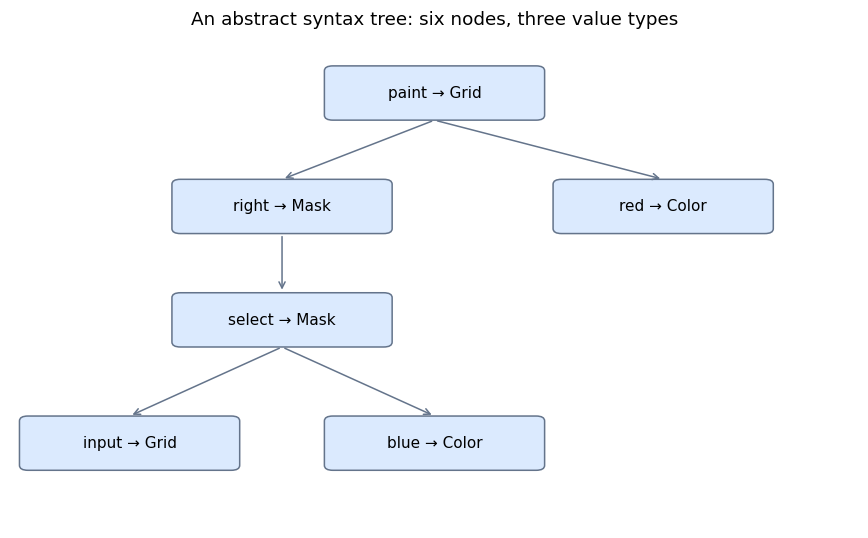

In [4]:
# Draw the syntax tree. Unlike the previous figure, positions now mean tree structure.
fig,ax=plt.subplots(figsize=(8,5)); ax.set(xlim=(0,1),ylim=(0,1)); ax.axis('off')
nodes=[(.5,.88,'paint → Grid'),(.32,.65,'right → Mask'),(.77,.65,'red → Color'),
       (.32,.42,'select → Mask'),(.14,.17,'input → Grid'),(.5,.17,'blue → Color')]
for parent,child in [(0,1),(0,2),(1,3),(3,4),(3,5)]:
    x,y,_=nodes[parent]; xx,yy,_=nodes[child]
    ax.annotate('',xy=(xx,yy+.055),xytext=(x,y-.055),arrowprops={'arrowstyle':'->','color':'#64748b'})
for x,y,label in nodes:
    ax.add_patch(FancyBboxPatch((x-.12,y-.045),.24,.09,boxstyle='round,pad=.01',facecolor='#dbeafe',edgecolor='#64748b'))
    ax.text(x,y,label,ha='center',va='center',fontsize=10)
ax.set_title('An abstract syntax tree: six nodes, three value types')
plt.tight_layout();plt.show()

## 4 · Examples constrain programs; they may not identify one

Our initial two examples place blue cells in column 1 of a four-column grid (zero-based
indexing). Both shifting right and reflecting horizontally move those cells to column 2.
The green distractors must disappear.

**Predict:** will a second example with a different number of blue cells, still in the same
column, distinguish the two rules? More examples need not mean more useful information.

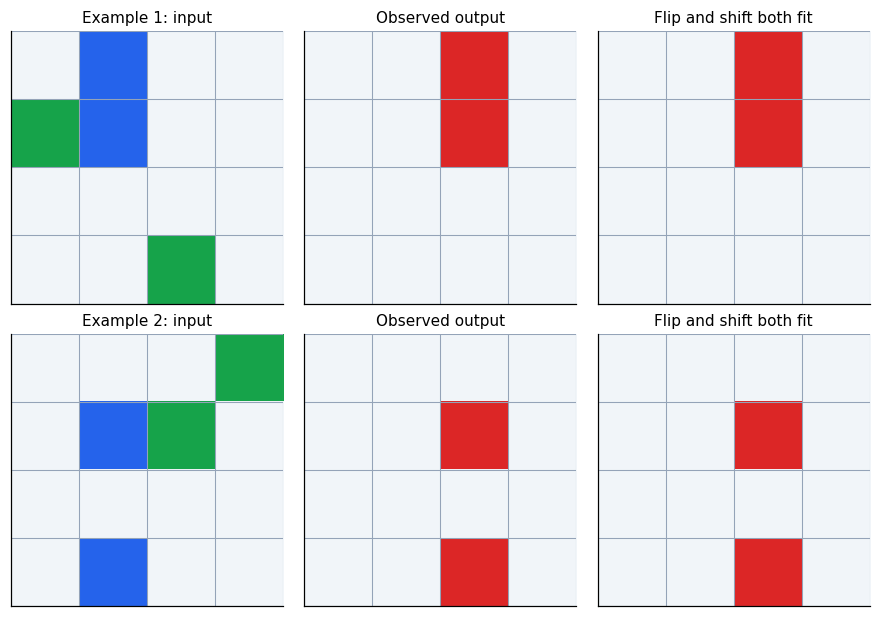

In [5]:
x_a=example.copy()
x_b=np.array([[0,0,0,3],[0,1,3,0],[0,0,0,0],[0,1,0,0]])
# Explicit labels, independent of the interpreter implementation.
y_a=np.array([[0,0,2,0],[0,0,2,0],[0,0,0,0],[0,0,0,0]])
y_b=np.array([[0,0,0,0],[0,0,2,0],[0,0,0,0],[0,0,2,0]])
train_inputs=[x_a,x_b]; train_outputs=[y_a,y_b]
for rule in [SHIFT_RULE,FLIP_RULE]:
    assert all(np.array_equal(interpret(rule,x),y) for x,y in zip(train_inputs,train_outputs))
fig,axes=plt.subplots(2,3,figsize=(8,5.5),layout='constrained')
for row,(x,y) in enumerate(zip(train_inputs,train_outputs)):
    show_grid(axes[row,0],x,f'Example {row+1}: input')
    show_grid(axes[row,1],y,'Observed output')
    show_grid(axes[row,2],interpret(FLIP_RULE,x),'Flip and shift both fit')
plt.show()

## 5 · Enumerate legal trees from small to large

A bottom-up enumerator starts with terminal nodes. For each operator it combines existing
children of the required types. A size-$n$ node with $k$ children satisfies
$1+s_1+\cdots+s_k=n$, with each $s_j\ge1$.

For `paint`, the first child must come from the Mask pool and the second from the Color pool.
We never generate `paint(red, input)` and then hope it works. Types guide construction.
The budget below is six nodes, counting constants and the input as nodes too.

This first implementation keeps **every syntactically distinct tree**. It does not merge
same-output programs or remove symmetric unions. It exhausts the bounded space instead of
stopping at the first fit, so we can inspect ambiguity. Ordering breaks ties; it is not evidence
that an equally small earlier program is more plausible.

All typed trees: 76 | grid candidates: 28
Programs consistent with both examples:
6 paint(flip(select(input, blue)), red)
6 paint(right(select(input, blue)), red)


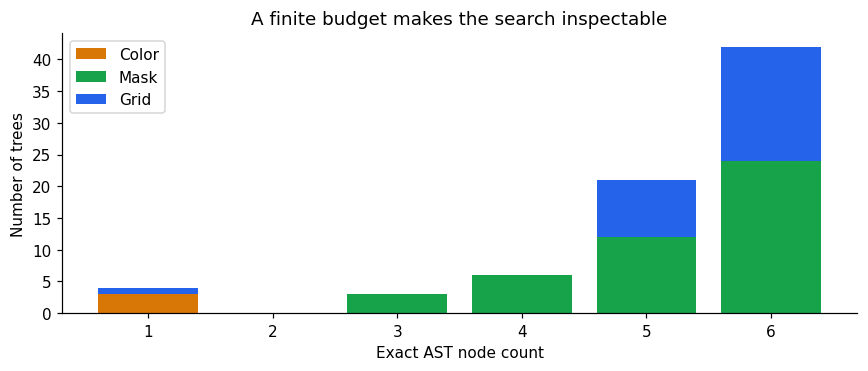

In [6]:
def size_partitions(total, count):
    if count==0:
        if total==0: yield ()
        return
    for first in range(1,total-count+2):
        for rest in size_partitions(total-first,count-1):
            yield (first,)+rest

def enumerate_typed(max_nodes):
    pools=defaultdict(list)  # (node_count, return_type) -> trees
    for name,(arguments,result_type) in SIGNATURES.items():
        if not arguments: pools[1,result_type].append(Expr(name))
    for size in range(2,max_nodes+1):
        for name,(argument_types,result_type) in SIGNATURES.items():
            if not argument_types: continue
            for sizes in size_partitions(size-1,len(argument_types)):
                choices=[pools[s,t] for s,t in zip(sizes,argument_types)]
                for children in product(*choices):
                    pools[size,result_type].append(Expr(name,tuple(children)))
    return pools

def consistent(expr, inputs, outputs):
    return all(np.array_equal(interpret(expr,x),y) for x,y in zip(inputs,outputs))

MAX_NODES=6
pools=enumerate_typed(MAX_NODES)
all_trees=[p for (size,typ),items in pools.items() for p in items]
grid_candidates=[p for size in range(1,MAX_NODES+1) for p in pools[size,'Grid']]
solutions=[p for p in grid_candidates if consistent(p,train_inputs,train_outputs)]
assert SHIFT_RULE in solutions and FLIP_RULE in solutions
assert len(all_trees)==len(set(all_trees))
for tree in all_trees: assert infer_type(tree) in {'Grid','Mask','Color'}
print('All typed trees:',len(all_trees),'| grid candidates:',len(grid_candidates))
print('Programs consistent with both examples:')
for tree in solutions: print(node_count(tree),pretty(tree))
fig,ax=plt.subplots(figsize=(8,3.5)); sizes=np.arange(1,MAX_NODES+1); bottom=np.zeros(MAX_NODES)
for typ,color in [('Color','#d97706'),('Mask','#16a34a'),('Grid','#2563eb')]:
    counts=np.array([len(pools[int(s),typ]) for s in sizes])
    ax.bar(sizes,counts,bottom=bottom,label=typ,color=color);bottom+=counts
ax.set(xlabel='Exact AST node count',ylabel='Number of trees',title='A finite budget makes the search inspectable')
ax.legend();fig.tight_layout();plt.show()

## 6 · Separate consistency, selection, and evaluation

Both candidate rules have the same size and zero training error. Choosing the first one
would silently turn registry order into a preference. We instead retain the version space:
the set of hypotheses consistent with the current examples.

A new **query input** with a blue cell in column 0 distinguishes the rules. Before seeing
its answer, the candidates predict different outputs. In this synthetic lab we supply the
shift-right answer. Once used to select a rule, that example is additional training evidence,
not a held-out test. We then evaluate on a separate, untouched example.

This is a manual illustration of informative example selection, not an implemented active
learning optimizer. In many real tasks you cannot request additional labels at all.

Surviving programs after additional evidence: ['paint(right(select(input, blue)), red)']
Held-out exact match: True


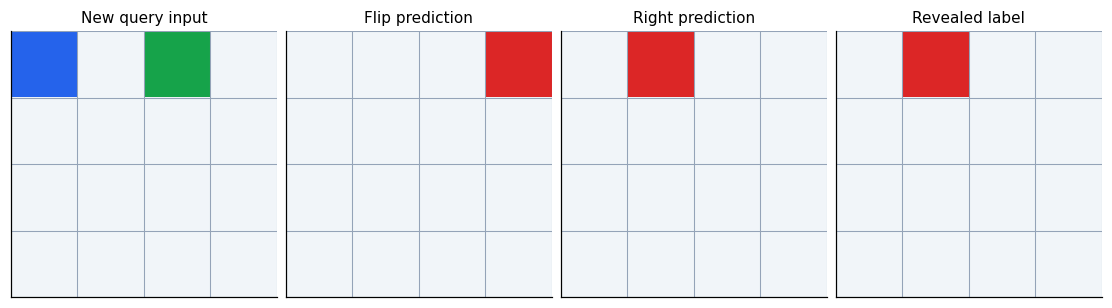

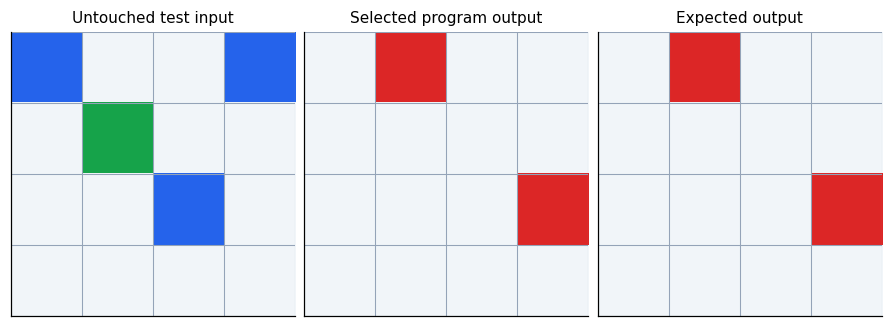

In [7]:
query=np.array([[1,0,3,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]])
query_answer=np.array([[0,2,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]])
fig,axes=plt.subplots(1,4,figsize=(10,3),layout='constrained')
for ax,g,title in zip(axes,[query,interpret(FLIP_RULE,query),interpret(SHIFT_RULE,query),query_answer],
                      ['New query input','Flip prediction','Right prediction','Revealed label']):
    show_grid(ax,g,title)
plt.show()
remaining=[p for p in solutions if consistent(p,[query],[query_answer])]
assert SHIFT_RULE in remaining and FLIP_RULE not in remaining
print('Surviving programs after additional evidence:',[pretty(p) for p in remaining])
assert len(remaining)==1  # uniqueness is only within this enumerated space
chosen=remaining[0]
x_test=np.array([[1,0,0,1],[0,3,0,0],[0,0,1,0],[0,0,0,0]])
y_test=np.array([[0,2,0,0],[0,0,0,0],[0,0,0,2],[0,0,0,0]])
predicted_test=interpret(chosen,x_test)
np.testing.assert_array_equal(predicted_test,y_test)
fig,axes=plt.subplots(1,3,figsize=(8,3),layout='constrained')
for ax,g,title in zip(axes,[x_test,predicted_test,y_test],['Untouched test input','Selected program output','Expected output']):
    show_grid(ax,g,title)
plt.show()
print('Held-out exact match:',np.array_equal(predicted_test,y_test))

## 7 · Behavioral signatures compress a search—and hide alternatives

For fixed inputs, define a signature as the output values across **all** examples, together
with their type, shapes, and dtypes. Two trees with the same signature are observationally
equivalent on that set. That does not prove equivalence on every possible input.

The next cell groups already-enumerated programs after the search. It illustrates compression;
it does **not** claim a measured search speedup. A scalable enumerator would group intermediate
results during construction, retaining the cheapest representative and avoiding redundant parents.

For our pure, deterministic, first-order operators, equal typed child values give equal parent
values on the same inputs. Substitution therefore preserves those observed results. Stateful
operations, context-dependent evaluation, or richer binding rules need additional care.

Crucially, merging preserves the ability to fit the **current** examples, not the full set of
hypotheses for future examples. If you retain only `flip`, new evidence may require a discarded
`right` representative. Keep provenance/alternatives or restart enumeration when evidence changes.

Grid trees: 28 | training behavior classes: 17
Matching class: ['paint(flip(select(input, blue)), red)', 'paint(right(select(input, blue)), red)']


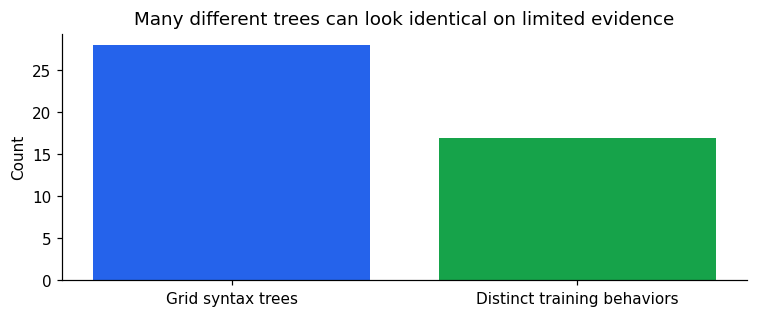

In [8]:
def freeze_value(value):
    arr=np.asarray(value)
    return (arr.shape,arr.dtype.str,arr.tobytes())
def signature(expr,inputs):
    return (infer_type(expr),tuple(freeze_value(interpret(expr,x)) for x in inputs))

classes=defaultdict(list)
for tree in grid_candidates: classes[signature(tree,train_inputs)].append(tree)
assert signature(FLIP_RULE,train_inputs)==signature(SHIFT_RULE,train_inputs)
assert signature(FLIP_RULE,train_inputs+[query])!=signature(SHIFT_RULE,train_inputs+[query])
representatives=[min(group,key=lambda p:(node_count(p),pretty(p))) for group in classes.values()]
assert {signature(p,train_inputs) for p in representatives}==set(classes)
print('Grid trees:',len(grid_candidates),'| training behavior classes:',len(classes))
print('Matching class:',[pretty(p) for p in classes[signature(SHIFT_RULE,train_inputs)]])
fig,ax=plt.subplots(figsize=(7,3))
ax.bar(['Grid syntax trees','Distinct training behaviors'],[len(grid_candidates),len(classes)],color=['#2563eb','#16a34a'])
ax.set(ylabel='Count',title='Many different trees can look identical on limited evidence')
fig.tight_layout();plt.show()

## 8 · Inverse semantics is a relation, not always a function

Forward execution asks: **given an input, what output results?** Inverse reasoning asks:
**given an output, which inputs could have produced it?** Formally the preimage is

$$f^{-1}(y)=\{x:f(x)=y\}.$$

This notation denotes a set, not necessarily an inverse function. A preimage may be empty,
have one member, or contain many members. `flip` is its own inverse. `right` loses the last
input column, so it has no unique inverse.

For a width-four row, the mapping is
$[a,b,c,d]\mapsto[0,a,b,c]$. Given $[0,0,1,0]$, the predecessors are $[0,1,0,0]$ and
$[0,1,0,1]$. If an output starts with True, it is impossible under zero-filled right shift.
For an $H$-row mask, a feasible target has $2^H$ predecessors: every cell in the last input
column is unconstrained. Enumerating them becomes unnecessary if we represent the constraints.

**Predict:** why does simply shifting the target left return only one possible predecessor?

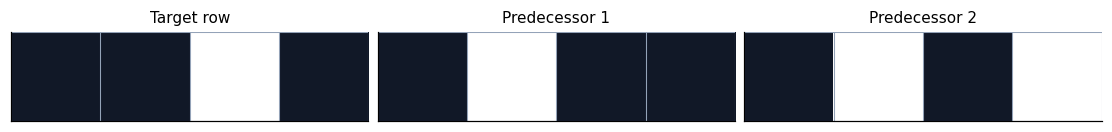

In [9]:
row_target=np.array([[False,False,True,False]])
rows=[np.array([bits],dtype=bool) for bits in product([False,True],repeat=4)]
preimages=[row for row in rows if np.array_equal(right(row),row_target)]
assert len(preimages)==2
fig,axes=plt.subplots(1,3,figsize=(10,2),layout='constrained')
show_grid(axes[0],row_target,'Target row',True)
for j,row in enumerate(preimages): show_grid(axes[j+1],row,f'Predecessor {j+1}',True)
plt.show()

## 9 · Represent a whole predecessor set with constraints

Use `-1` for unknown, `0` for required False, and `1` for required True. For a feasible
shift target, columns except the last are fixed by the target's columns 1 onward; the last
column remains unknown. `None` denotes an impossible target, distinct from a mask of False.

This representation is exact for this operator. More complicated inverses may need coupled
constraints. For example, inverting union cannot generally be described by assigning each
operand an independent concrete mask. A backward rule must not throw away valid possibilities.

Inverse relation checked for all 256 four-cell input/target pairs and width-one boundary.


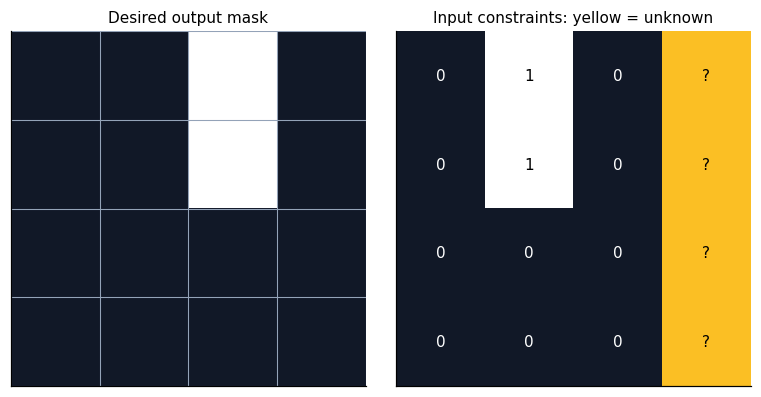

In [10]:
def inverse_right(target):
    target=np.asarray(target)
    if target.ndim!=2 or min(target.shape)==0 or target.dtype!=bool:
        raise ValueError('Expected a nonempty 2D Boolean target')
    if target[:,0].any(): return None
    constraints=np.full(target.shape,-1,dtype=np.int8)
    constraints[:,:-1]=target[:,1:]
    return constraints

def satisfies(mask,constraints):
    if constraints is None or mask.shape!=constraints.shape: return False
    known=constraints!=-1
    return bool(np.all(mask[known]==constraints[known]))

constraints=inverse_right(y_a==2)
fig,axes=plt.subplots(1,2,figsize=(7,3.5),layout='constrained')
show_grid(axes[0],y_a==2,'Desired output mask',True)
axes[1].imshow(constraints,cmap=ListedColormap(['#fbbf24','#111827','#ffffff']),vmin=-1,vmax=1)
axes[1].set_title('Input constraints: yellow = unknown',fontsize=10)
for (r,c),value in np.ndenumerate(constraints):
    axes[1].text(c,r,'?' if value==-1 else str(value),ha='center',va='center',color='white' if value==0 else 'black')
axes[1].set_xticks([]);axes[1].set_yticks([]);plt.show()
# Exhaustively check all 16 inputs × all 16 targets for four-cell rows.
for target in rows:
    constraint=inverse_right(target)
    for candidate in rows:
        assert satisfies(candidate,constraint)==np.array_equal(right(candidate),target)
assert inverse_right(np.array([[True,False]],dtype=bool)) is None
# Also check width-one masks, whose right shift is always all False.
assert inverse_right(np.array([[False]],dtype=bool))[0,0]==-1
print('Inverse relation checked for all 256 four-cell input/target pairs and width-one boundary.')

## 10 · Meet forward candidates with a backward requirement

Suppose we hypothesize the outer structure `paint(right(HOLE), red)`. Backward reasoning
first asks whether the target uses only background and red; if so, the needed painted mask
is exactly `target == red`. The inverse of `right` then constrains the hole.

Forward enumeration supplies candidate Mask expressions for that hole. We keep those whose
values satisfy the constraints on every example, then execute the complete program as a
final check. This is **sketch completion with a fixed outer structure**, not a complete
bidirectional search engine. It shows the interface a larger search could use.

The sketch uses three nodes outside the hole (paint, right, red), leaving three nodes for
the hole under our six-node budget. We now use the two original examples plus the revealed
query as training evidence. The held-out example remains outside this search.

In [11]:
def inverse_paint(target,color):
    if np.any((target!=0)&(target!=color)): return None
    return target==color  # exact because color is nonzero in this DSL

def complete_sketch(inputs,outputs,hole_candidates):
    requirements=[]
    for target in outputs:
        needed_mask=inverse_paint(target,2)
        requirement=None if needed_mask is None else inverse_right(needed_mask)
        if requirement is None: return []
        requirements.append(requirement)
    completed=[]
    for hole in hole_candidates:
        if infer_type(hole)!='Mask': continue
        if all(satisfies(interpret(hole,x),r) for x,r in zip(inputs,requirements)):
            full=Expr('paint',(Expr('right',(hole,)),RED))
            assert consistent(full,inputs,outputs)
            completed.append(full)
    return completed

expanded_inputs=train_inputs+[query]; expanded_outputs=train_outputs+[query_answer]
holes=[tree for size in range(1,4) for tree in pools[size,'Mask']]
completed=complete_sketch(expanded_inputs,expanded_outputs,holes)
assert completed==[SHIFT_RULE]
print('Forward hole candidates:',[pretty(h) for h in holes])
print('Completed sketch:',[pretty(p) for p in completed])
# Cross-check the backward filter against direct execution of every possible filled sketch.
brute=[Expr('paint',(Expr('right',(h,)),RED)) for h in holes]
brute=[p for p in brute if consistent(p,expanded_inputs,expanded_outputs)]
assert set(completed)==set(brute)

Forward hole candidates: ['select(input, blue)', 'select(input, red)', 'select(input, green)']
Completed sketch: ['paint(right(select(input, blue)), red)']


## 11 · What the search has—and has not—established

Within the six-node grammar, the additional query leaves one consistent Grid program.
This bounded uniqueness is not a theorem that no other rule could explain the data.
Larger trees, another language, or conditional rules can introduce new hypotheses.
A single held-out success demonstrates one generalization case, not broad ARC competence.

Three kinds of pruning must be distinguished:

| Decision | What justifies it? | What it does not establish |
|---|---|---|
| Type rejection | Operator cannot consume those child types | Semantically useful programs remain only if grammar is adequate |
| Behavioral merging | Same typed values on current examples, under substitutable semantics | Global equivalence or preservation of every future hypothesis |
| Inverse filtering | Candidate violates a valid backward constraint | Correctness of an approximate inverse unless checked |

A larger system needs evaluation budgets, caching, stronger types, and a way to prioritize
expansions. This notebook establishes the objects those algorithms operate on. Later lessons
will add probabilistic preferences, tree search, and learned guidance.

For your grid/gene work, a useful separation is: **program tree** (how produced), **execution
value** (what it produced), and **behavioral signature** (how it behaved across examples).
Merging values without retaining useful provenance can erase alternatives worth exploring.

## 12 · Exercises: predict, implement, explain

1. **Count a tree.** What is the type and node count of
   `union(select(input, blue), select(input, green))`? Can our six-node search construct it?
2. **Add a vertical reflection.** Add a Mask → Mask operation. Specify its interpreter rule
   and an example that distinguishes it from horizontal reflection. What else must change
   for the enumerator to discover it?
3. **Distinguishing input.** Construct a four-column input where both learned candidates
   output different grids, without using column 0. Explain why it works.
4. **Inverse cardinality.** How many predecessors does a feasible right-shift target have
   for a three-row, five-column mask? What changes if its first column contains True?
5. **Union backward.** For one output cell of `union(a,b)`, enumerate the allowed pairs
   `(a,b)` when the output is False and when it is True. Why is choosing just one pair unsound?
6. **Budget versus expressibility.** Add a task that moves blue cells two steps right and
   paints them red. What node budget does the obvious expression require? How would you
   distinguish failure due to too small a budget from failure due to missing operators?
7. **Observe information loss.** Construct two distinct 2D masks with the same right-shift
   output. Explain why an inverse routine returning a single concrete mask cannot capture both.

Stop here before reading the solutions. After changing the registry or examples, rebuild
all dependent pools and signatures; cached results from a different language/evidence set are stale.

## 13 · Solutions and reasoning

1. Its type is Mask; its size is $1+3+3=7$. Six nodes cannot construct it. A well-typed
   expression can still exceed the search budget.
2. Add `'updown': (('Mask',), 'Mask')` and return `values[0][::-1,:].copy()` in `apply_op`.
   The signature-driven enumerator needs no new construction case; rebuild its pools.
   A singleton at the top-left of a nonsquare mask distinguishes the two reflections.
3. Put a blue cell in column 2. Right moves it to 3, while flip moves it to 1. Or use
   column 3, where right drops it and flip moves it to 0.
4. There are $2^3=8$ predecessors: one independent unknown per row in the last input column.
   A True first output column makes the preimage empty.
5. False allows only `(False,False)`. True allows `(True,False)`, `(False,True)`, and
   `(True,True)`. Choosing a single pair discards other valid explanations. The operands'
   constraints are coupled by their OR relation.
6. `paint(right(right(select(input,blue))),red)` has seven nodes. The expression is already
   in this grammar; the six-node budget hides it. Increasing the budget and finding it
   diagnoses that case. Failure at any finite budget does not prove no expression exists
   in the unbounded grammar. Proving non-expressibility needs a structural argument.
7. Change any cell in the last input column and keep all others fixed. Right shift drops
   that difference. A concrete left-shift reconstruction chooses zeros for the lost column;
   the constraint representation correctly leaves those cells unknown.

## 14 · Reconstruct it without looking

You should be able to define syntax separately from semantics, type-check a tree, execute
it recursively, enumerate by node count, retain competing hypotheses, and derive an exact
preimage constraint for a lossy operation. You should also explain why fresh evidence can
split a previously merged behavioral class.

**Vocabulary:** *DSL* is a domain-specific language; *AST* is an abstract syntax tree;
*denotation* is the meaning of a program; *version space* contains hypotheses consistent
with evidence; *observational equivalence* means agreement on specified observations;
*preimage* is a set of inputs yielding an output; *sketch* is a program with holes.

### Primary reading and scope

- Solar-Lezama and Olausson, [Introduction to Program Synthesis, Lecture 3: Bottom Up Explicit Search](https://people.csail.mit.edu/asolar/SynthesisCourse/Lecture3.htm).
  Further treatment of enumerative search and the conditions for behavioral substitution.
- Alford et al., [Neural-guided, Bidirectional Program Search for Abstraction and Reasoning](https://arxiv.org/abs/2110.11536).
  A research example combining learned guidance with inverse semantics; our fixed-sketch
  demonstration is not a reproduction of that system.

The language, examples, interpreter, exhaustive checks, and figures here are original
teaching constructions. No research benchmark result is claimed.

**Next: 03 — choosing among hypotheses with Bayesian reasoning, description length, and uncertainty.**